In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [4]:
df = pd.read_csv("customer_churn_data.csv")

In [5]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [6]:
df.tail()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,NaN,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,NaN,4465.56,No,Yes
999,1000,50,Male,1,56.67,Month-to-Month,NaN,56.67,No,Yes


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [10]:
df.isna().sum().sum()

np.int64(297)

In [11]:
df["InternetService"] = df["InternetService"].fillna("")

In [14]:
df.isna().sum().sum()

np.int64(0)

In [15]:
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes
...,...,...,...,...,...,...,...,...,...,...
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,,4465.56,No,Yes


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes


In [19]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [22]:
numeric_columns_data = df.select_dtypes(include = ["number"])

In [23]:
numeric_columns_data

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
0,1,49,4,88.35,353.40
1,2,43,0,36.67,0.00
2,3,51,2,63.79,127.58
3,4,60,8,102.34,818.72
4,5,42,32,69.01,2208.32
...,...,...,...,...,...
995,996,42,41,37.14,1522.74
996,997,62,9,80.93,728.37
997,998,51,15,111.72,1675.80
998,999,39,68,65.67,4465.56


In [24]:
numeric_columns_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


In [27]:
#-1               1
#strong negative  strong positive

In [28]:
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes
...,...,...,...,...,...,...,...,...,...,...
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,,4465.56,No,Yes


In [30]:
df["Churn"].value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

In [33]:
df["Churn"].value_counts(normalize=True) * 100

Churn
Yes    88.3
No     11.7
Name: proportion, dtype: float64

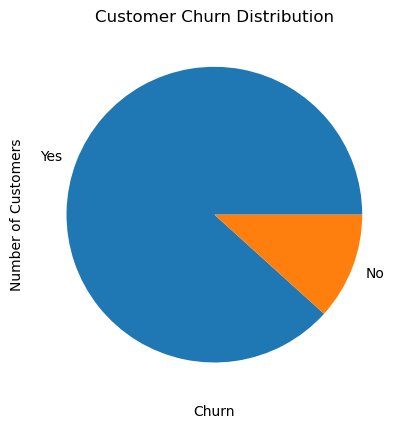

In [34]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="pie")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [35]:
pd.crosstab(
    df["ContractType"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
ContractType,,
Month-to-Month,0.000000,100.000000
One-Year,24.567474,75.432526
Two-Year,23.000000,77.000000


In [36]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TechSupport,,
No,0.00000,100.00000
Yes,23.12253,76.87747


In [37]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
,0.000000,100.000000
DSL,15.584416,84.415584
Fiber Optic,17.468354,82.531646


In [38]:
df.groupby("Churn")["Tenure"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn,,,,
No,30.264957,25.0,12,98
Yes,17.476784,11.0,0,122


In [39]:
df.groupby("Churn")["MonthlyCharges"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn,,,,
No,62.54641,60.64,30.97,98.99
Yes,75.96077,78.63,30.00,119.96


In [40]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

X = df.drop(columns=["Churn", "CustomerID"])
y = df["Churn"]

In [41]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['Gender', 'ContractType', 'InternetService', 'TechSupport']


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [44]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
y_pred = logistic_model.predict(X_test)

y_probability = logistic_model.predict_proba(X_test)[:, 1]

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall:",
      recall_score(y_test, y_pred))

print("F1 Score:",
      f1_score(y_test, y_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, y_probability))

Accuracy: 0.935
Precision: 1.0
Recall: 0.9265536723163842
F1 Score: 0.9618768328445748
ROC-AUC: 0.9926308032424467


In [47]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
rf_pred = random_forest.predict(X_test)

rf_probability = random_forest.predict_proba(
    X_test
)[:, 1]

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, rf_probability))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [50]:
random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [51]:
random_forest.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [52]:
rf_pred = random_forest.predict(X_test)

rf_probability = random_forest.predict_proba(X_test)[:, 1]

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Random Forest Results")
print("---------------------")

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, rf_probability))

Random Forest Results
---------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


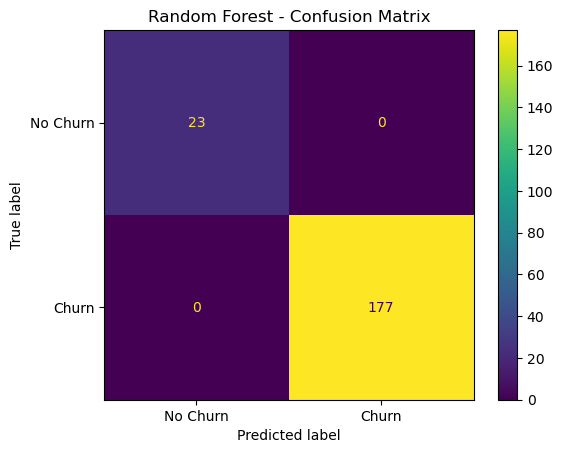

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["No Churn", "Churn"]
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [55]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00        23
       Churn       1.00      1.00      1.00       177

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [56]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    random_forest,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

In [57]:
for metric in [
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_roc_auc"
]:
    scores = cv_results[metric]

    print(
        f"{metric}: "
        f"{scores.mean():.4f} "
        f"+/- {scores.std():.4f}"
    )

test_accuracy: 0.9990 +/- 0.0020
test_precision: 0.9989 +/- 0.0023
test_recall: 1.0000 +/- 0.0000
test_f1: 0.9994 +/- 0.0011
test_roc_auc: 1.0000 +/- 0.0000


In [58]:
print(
    pd.crosstab(
        df["ContractType"],
        df["Churn"],
        normalize="index"
    ) * 100
)

Churn                   0           1
ContractType                         
Month-to-Month   0.000000  100.000000
One-Year        24.567474   75.432526
Two-Year        23.000000   77.000000


In [59]:
print(
    pd.crosstab(
        df["TechSupport"],
        df["Churn"],
        normalize="index"
    ) * 100
)

Churn               0          1
TechSupport                     
No            0.00000  100.00000
Yes          23.12253   76.87747


In [60]:
print(
    pd.crosstab(
        df["InternetService"],
        df["Churn"],
        normalize="index"
    ) * 100
)

Churn                    0           1
InternetService                       
                  0.000000  100.000000
DSL              15.584416   84.415584
Fiber Optic      17.468354   82.531646


In [61]:
rf_preprocessor = random_forest.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

importances = random_forest.named_steps[
    "classifier"
].feature_importances_

In [62]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
6,cat__ContractType_Month-to-Month,0.236275
1,num__Tenure,0.191549
12,cat__TechSupport_No,0.143244
13,cat__TechSupport_Yes,0.141205
3,num__TotalCharges,0.088849
2,num__MonthlyCharges,0.082974
7,cat__ContractType_One-Year,0.039992
9,cat__InternetService_,0.029643
8,cat__ContractType_Two-Year,0.026451
0,num__Age,0.009613


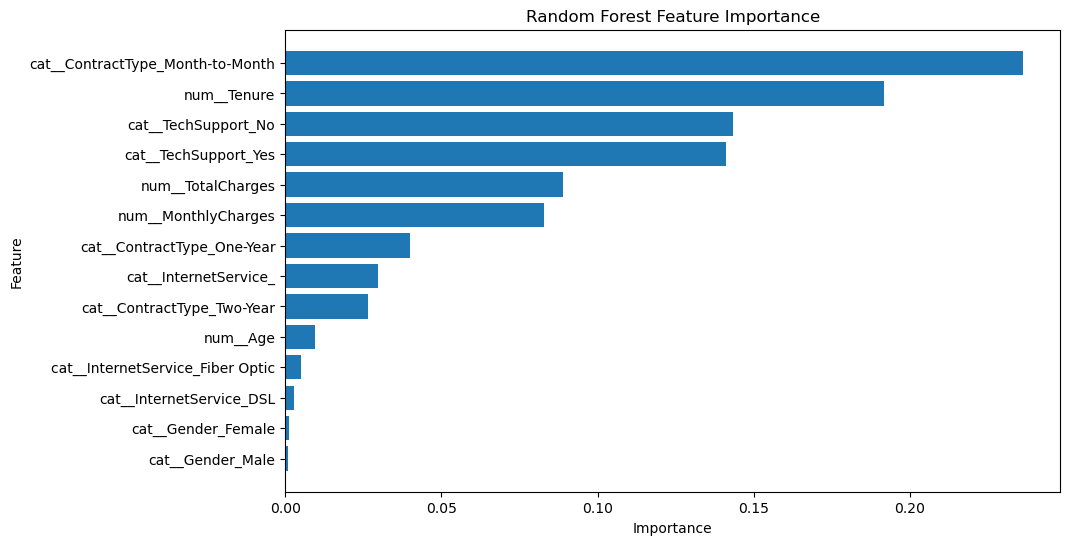

In [63]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

In [64]:
from sklearn.model_selection import GridSearchCV

In [65]:
param_grid = {
    "classifier__n_estimators": [100, 300, 500],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

In [66]:
grid_search = GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [67]:
grid_search.fit(X, y)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [68]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


In [69]:
print("Best CV ROC-AUC:")
print(grid_search.best_score_)

Best CV ROC-AUC:
1.0


In [70]:
best_model = grid_search.best_estimator_

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [72]:
best_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [73]:
final_pred = best_model.predict(X_test)

final_probability = best_model.predict_proba(
    X_test
)[:, 1]

In [74]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Final Model Results")
print("-------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, final_pred)
)

print(
    "Precision:",
    precision_score(y_test, final_pred)
)

print(
    "Recall:",
    recall_score(y_test, final_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, final_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, final_probability)
)

Final Model Results
-------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


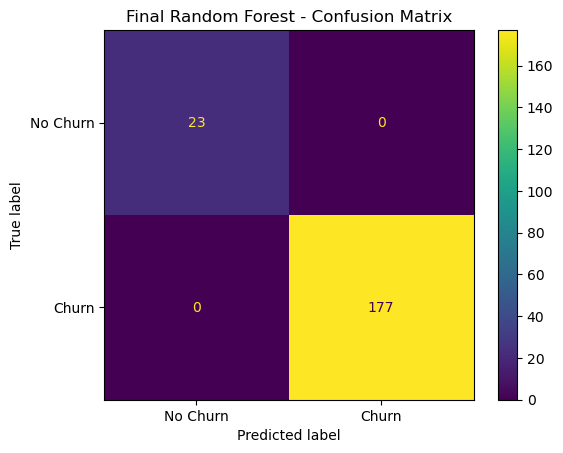

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    display_labels=["No Churn", "Churn"]
)

plt.title("Final Random Forest - Confusion Matrix")
plt.show()

In [76]:
import joblib

joblib.dump(
    best_model,
    "churn_prediction_model.pkl"
)

['churn_prediction_model.pkl']

In [77]:
import os

print(
    os.path.getsize("churn_prediction_model.pkl"),
    "bytes"
)

442523 bytes


In [78]:
# Extract the preprocessing pipeline
rf_preprocessor = best_model.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = rf_preprocessor.get_feature_names_out()

# Get feature importance from Random Forest
importances = best_model.named_steps[
    "classifier"
].feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
6,cat__ContractType_Month-to-Month,0.225660
1,num__Tenure,0.204964
13,cat__TechSupport_Yes,0.140834
12,cat__TechSupport_No,0.128128
2,num__MonthlyCharges,0.090426
3,num__TotalCharges,0.079461
7,cat__ContractType_One-Year,0.047986
9,cat__InternetService_,0.032745
8,cat__ContractType_Two-Year,0.027245
0,num__Age,0.010580


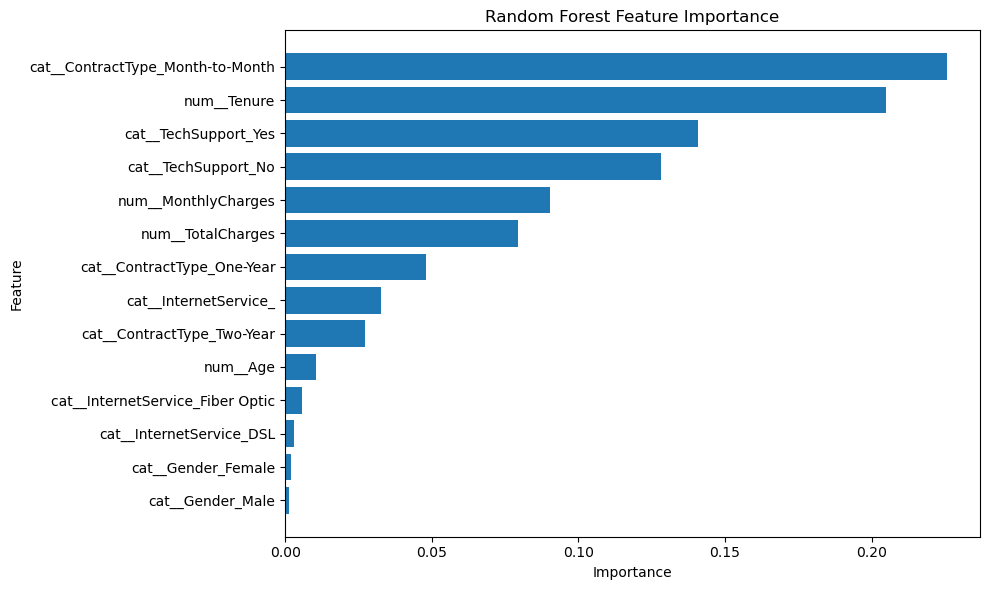

In [79]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [80]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [81]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [82]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

In [83]:
preprocessor = best_model.named_steps["preprocessor"]
rf_model = best_model.named_steps["classifier"]

X_test_transformed = preprocessor.transform(X_test)

In [84]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(
    X_test_transformed
)

In [85]:
shap_values[0]
shap_values[1]

array([[-1.96699090e-03,  1.96699090e-03],
       [ 2.36963878e-02, -2.36963878e-02],
       [ 9.92160667e-03, -9.92160667e-03],
       [ 1.12731929e-02, -1.12731929e-02],
       [-6.78617696e-05,  6.78617696e-05],
       [-9.26820657e-05,  9.26820657e-05],
       [-1.79572845e-01,  1.79572845e-01],
       [-5.19005706e-02,  5.19005706e-02],
       [-2.73118858e-02,  2.73118858e-02],
       [ 5.10891300e-03, -5.10891300e-03],
       [-1.32202833e-03,  1.32202833e-03],
       [ 2.59540858e-03, -2.59540858e-03],
       [-1.39031608e-01,  1.39031608e-01],
       [-1.45685621e-01,  1.45685621e-01]])

In [86]:
feature_names = preprocessor.get_feature_names_out()

In [89]:
shap_values[1]

array([[-1.96699090e-03,  1.96699090e-03],
       [ 2.36963878e-02, -2.36963878e-02],
       [ 9.92160667e-03, -9.92160667e-03],
       [ 1.12731929e-02, -1.12731929e-02],
       [-6.78617696e-05,  6.78617696e-05],
       [-9.26820657e-05,  9.26820657e-05],
       [-1.79572845e-01,  1.79572845e-01],
       [-5.19005706e-02,  5.19005706e-02],
       [-2.73118858e-02,  2.73118858e-02],
       [ 5.10891300e-03, -5.10891300e-03],
       [-1.32202833e-03,  1.32202833e-03],
       [ 2.59540858e-03, -2.59540858e-03],
       [-1.39031608e-01,  1.39031608e-01],
       [-1.45685621e-01,  1.45685621e-01]])

X shape: (200, 14)
SHAP type: <class 'numpy.ndarray'>
SHAP shape: (200, 14, 2)
Final SHAP shape: (200, 14)
Number of features: 14


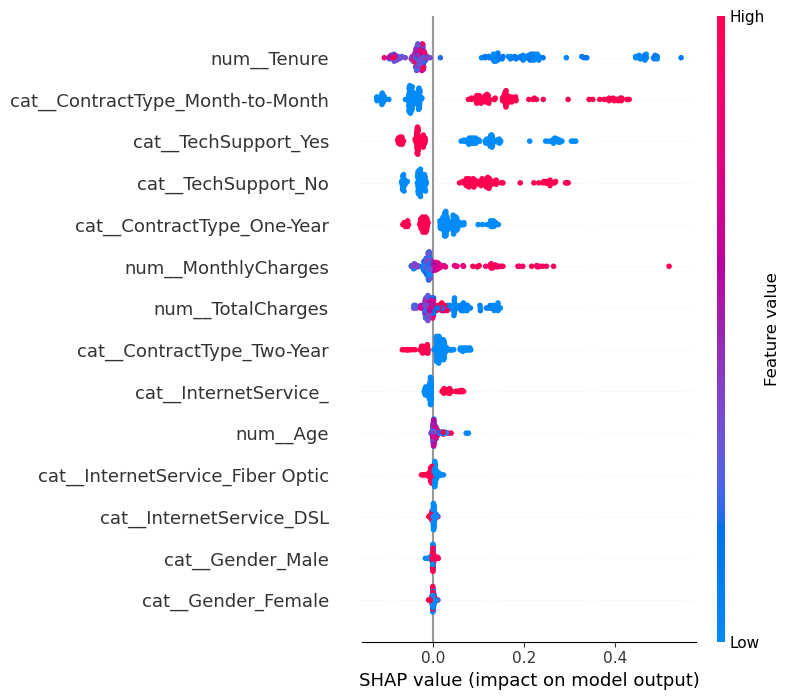

In [91]:
import numpy as np
import shap

# ---------------------------------------
# 1. Get preprocessing and Random Forest
# ---------------------------------------

preprocessor = best_model.named_steps["preprocessor"]
rf_model = best_model.named_steps["classifier"]


# ---------------------------------------
# 2. Transform test data
# ---------------------------------------

X_test_transformed = preprocessor.transform(X_test)

# Convert sparse matrix to dense if necessary
if hasattr(X_test_transformed, "toarray"):
    X_test_shap = X_test_transformed.toarray()
else:
    X_test_shap = X_test_transformed


# ---------------------------------------
# 3. Create SHAP explainer
# ---------------------------------------

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_shap)


# ---------------------------------------
# 4. Inspect shapes
# ---------------------------------------

print("X shape:", X_test_shap.shape)
print("SHAP type:", type(shap_values))
print("SHAP shape:", np.shape(shap_values))


# ---------------------------------------
# 5. Select Churn class
# ---------------------------------------

if isinstance(shap_values, list):

    # Older SHAP versions
    shap_values_churn = shap_values[1]

elif len(shap_values.shape) == 3:

    # Newer SHAP versions
    shap_values_churn = shap_values[:, :, 1]

else:

    # Binary/single-output
    shap_values_churn = shap_values


print(
    "Final SHAP shape:",
    shap_values_churn.shape
)


# ---------------------------------------
# 6. Feature names
# ---------------------------------------

feature_names = preprocessor.get_feature_names_out()

print(
    "Number of features:",
    len(feature_names)
)


# ---------------------------------------
# 7. SHAP Summary Plot
# ---------------------------------------

shap.summary_plot(
    shap_values_churn,
    X_test_shap,
    feature_names=feature_names
)

In [92]:
customer_index = 0

customer = X_test.iloc[[customer_index]]

print(customer)

     Age  Gender  Tenure  MonthlyCharges    ContractType InternetService  \
295   38  Female      32           45.79  Month-to-Month     Fiber Optic   

     TotalCharges TechSupport  
295       1465.28         Yes  


In [93]:
customer_index = 0

customer = X_test.iloc[[customer_index]]

print(customer)

     Age  Gender  Tenure  MonthlyCharges    ContractType InternetService  \
295   38  Female      32           45.79  Month-to-Month     Fiber Optic   

     TotalCharges TechSupport  
295       1465.28         Yes  


In [95]:
# Select one customer from the test dataset
customer_index = 0
customer = X_test.iloc[[customer_index]]

# Get prediction probability
probability = best_model.predict_proba(customer)[0][1]

# Get prediction
prediction = int(probability >= 0.5)

# Determine risk level
if probability < 0.40:
    risk_level = "Low"
elif probability < 0.70:
    risk_level = "Medium"
else:
    risk_level = "High"

# Display result
print("=" * 45)
print("       CUSTOMER CHURN PREDICTION")
print("=" * 45)

print(f"Churn Probability : {probability * 100:.2f}%")
print(f"Risk Level        : {risk_level}")

if prediction == 1:
    print("Prediction        : Customer likely to CHURN")
else:
    print("Prediction        : Customer likely to STAY")

print("=" * 45)

       CUSTOMER CHURN PREDICTION
Churn Probability : 100.00%
Risk Level        : High
Prediction        : Customer likely to CHURN


In [96]:
# Transform the selected customer
customer_transformed = preprocessor.transform(customer)

# Convert sparse matrix to dense if necessary
if hasattr(customer_transformed, "toarray"):
    customer_transformed = customer_transformed.toarray()

# Calculate SHAP values
customer_shap = explainer.shap_values(customer_transformed)

# Handle SHAP output format
if isinstance(customer_shap, list):

    customer_shap_churn = customer_shap[1]

elif len(customer_shap.shape) == 3:

    customer_shap_churn = customer_shap[:, :, 1]

else:

    customer_shap_churn = customer_shap

print("Customer data shape:", customer_transformed.shape)
print("SHAP shape:", customer_shap_churn.shape)

Customer data shape: (1, 14)
SHAP shape: (1, 14)


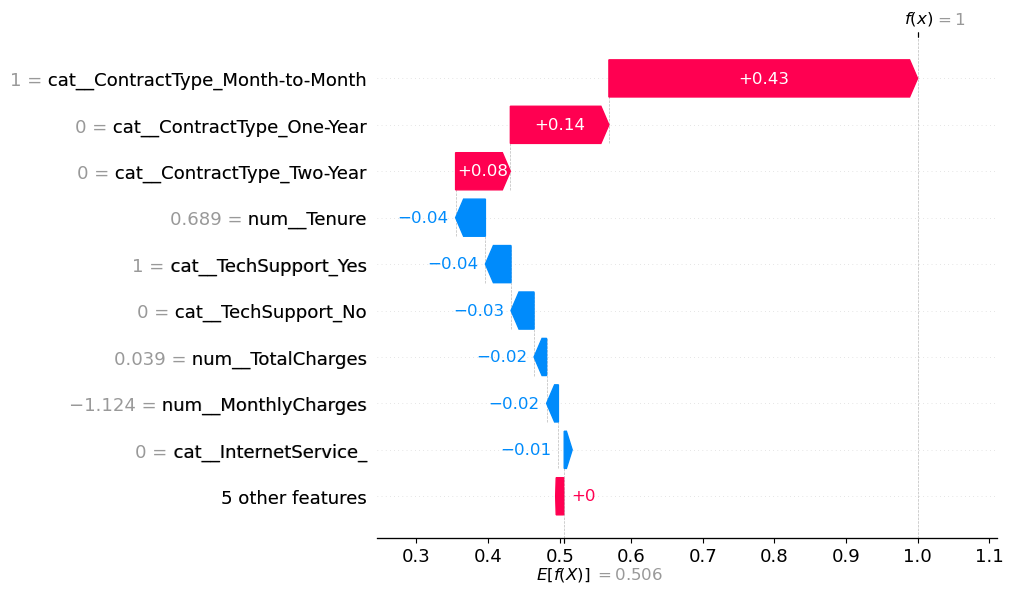

In [97]:
shap.waterfall_plot(
    shap.Explanation(
        values=customer_shap_churn[0],
        base_values=explainer.expected_value[1],
        data=customer_transformed[0],
        feature_names=feature_names
    )
)

In [98]:
explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Value": customer_shap_churn[0]
})

explanation["Impact"] = explanation["SHAP Value"].apply(
    lambda x: "Increases Churn" if x > 0
    else "Decreases Churn"
)

explanation["Absolute Impact"] = (
    explanation["SHAP Value"].abs()
)

explanation = explanation.sort_values(
    by="Absolute Impact",
    ascending=False
)

explanation.head(10)

,Feature,SHAP Value,Impact,Absolute Impact
6,cat__ContractType_Month-to-Month,0.431168,Increases Churn,0.431168
7,cat__ContractType_One-Year,0.137666,Increases Churn,0.137666
8,cat__ContractType_Two-Year,0.076472,Increases Churn,0.076472
1,num__Tenure,-0.041625,Decreases Churn,0.041625
13,cat__TechSupport_Yes,-0.035777,Decreases Churn,0.035777
12,cat__TechSupport_No,-0.032176,Decreases Churn,0.032176
3,num__TotalCharges,-0.017533,Decreases Churn,0.017533
2,num__MonthlyCharges,-0.016501,Decreases Churn,0.016501
9,cat__InternetService_,-0.008092,Decreases Churn,0.008092
11,cat__InternetService_Fiber Optic,-0.004984,Decreases Churn,0.004984
